# 1. Exploración y comprensión de los datos

## 1.1. Descarga del _dataset_ "AirBnb Buenos Aires"

In [20]:
import urllib.request
urllib.request.urlretrieve("https://data.insideairbnb.com/argentina/ciudad-aut%C3%B3noma-de-buenos-aires/buenos-aires/2026-01-25/visualisations/listings.csv.gz", "./data/listings-airbnb-ba.csv.gz")

('./data/listings-airbnb-ba.csv.gz', <http.client.HTTPMessage at 0x118e908a0>)

In [21]:
import pandas
df = pandas.read_csv('./data/listings-airbnb-ba.csv.gz')

## 1.2. Verificación preliminar

In [22]:
df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,42610838,"Puerto Madero a 3 cuadras, centro, bello , tea...",224049389,1469188629918707060,Gabriela,NaN,San Nicolas,-34.599976,-58.374195,Entire home/apt,NaN,7.0,0,NaN,NaN,2,244,0,NaN
1,1305876403852901802,Apart estudio en Microcentro,25649070,1465347917068117288,Federico,NaN,San Nicolas,-34.600382,-58.372692,Entire home/apt,NaN,2.0,1,2025-01-18,0.08,1,307,0,NaN
2,1542233033640525302,"Departamento en Buenos Aires, abasto shopping",153014015,1468500000533080859,Marco,NaN,Balvanera,-34.603295,-58.409527,Entire home/apt,NaN,7.0,0,NaN,NaN,1,326,0,NaN
3,1004530078359434134,Departamento en Recoleta,1409800,1462517876404348407,Marian,NaN,Balvanera,-34.599230,-58.407060,Entire home/apt,NaN,1.0,22,2025-12-07,0.80,39,365,3,NaN
4,800145927121871422,Coqueto para 4 personas,467965425,1470109782901816721,Maria Del Carmen,NaN,Almagro,-34.599767,-58.426499,Entire home/apt,NaN,1.0,0,NaN,NaN,2,365,0,NaN


In [23]:
df.tail()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
27343,1587119060096878911,Estudio luminoso en el corazón de Villa Crespo.,1534662,1462518725032785871,Florencia,NaN,Villa Crespo,-34.597425,-58.442220,Entire home/apt,NaN,1.0,1,2026-01-10,1.00,6,54,1,NaN
27344,37623532,Modern Top located Duplex Apartment! Up to 4 pax,2809500,1462609256411099848,Florencia,NaN,Palermo,-34.575020,-58.421840,Entire home/apt,NaN,30.0,12,2025-03-17,0.16,3,344,1,NaN
27345,1074846345919500333,Departamento Villa crespo I,133597828,1462947748907784667,Estudio H Apartments,NaN,Villa Crespo,-34.594473,-58.441314,Entire home/apt,NaN,2.0,4,2025-12-10,0.36,6,84,4,NaN
27346,1028342669639305203,"Depto a 8 min de Palermo,subte línea B 100 Mts.",49955010,1465763312015870684,Mariano,NaN,Villa Crespo,-34.600277,-58.437097,Entire home/apt,NaN,3.0,4,2025-12-05,0.15,1,269,3,NaN
27347,18517386,Apartment Full Equipment in Belgrano R,57658152,1466691284640462108,Ines,NaN,Belgrano,-34.568100,-58.456000,Entire home/apt,NaN,1.0,59,2025-12-31,0.56,1,44,2,NaN


## 1.3. Exploración de datos

Se visualiza tamaño del conjunto de datos, el número de elementos totales y el tipo de datos.
Se distinguen también las variables numéricas y categóricas.

In [24]:
print(f"Tamaño del conjunto de datos: {df.shape}\n")
print(f"Total de elementos: {df.size}\n")
print(f"Tipos de datos: \n{df.dtypes}\n")

Tamaño del conjunto de datos: (27348, 19)

Total de elementos: 519612

Tipos de datos: 
id                                  int64
name                                  str
host_id                             int64
host_profile_id                     int64
host_name                             str
neighbourhood_group               float64
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                               str
dtype: object



In [25]:
# Se distinguen variables númericas discretas y continuas
print(f"Variables numéricas discretas: {df.select_dtypes(include=['int']).columns.tolist()}\n")
print(f"Variables numéricas continuas: {df.select_dtypes(include=['float']).columns.tolist()}\n")
print(f"Número de variables numéricas: {len(df.select_dtypes(include=['number']).columns)}, de las cuales {len(df.select_dtypes(include=['int']).columns)} son discretas y {len(df.select_dtypes(include=['float']).columns)} son continuas\n")
# Se verifican las variables categóricas
print(f"Variables categóricas: {df.select_dtypes(include=['str']).columns.tolist()}\n")
# Número de variables categóricas
print(f"Número de variables categóricas: {len(df.select_dtypes(include=['str']).columns)}, de las cuales {len(df.select_dtypes(include=['category']).columns)} son ordinales y {len(df.select_dtypes(include=['str']).columns) - len(df.select_dtypes(include=['category']).columns)} son nominales\n")

Variables numéricas discretas: ['id', 'host_id', 'host_profile_id', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm']

Variables numéricas continuas: ['neighbourhood_group', 'latitude', 'longitude', 'price', 'minimum_nights', 'reviews_per_month']

Número de variables numéricas: 13, de las cuales 7 son discretas y 6 son continuas

Variables categóricas: ['name', 'host_name', 'neighbourhood', 'room_type', 'last_review', 'license']

Número de variables categóricas: 6, de las cuales 0 son ordinales y 6 son nominales



Curiosidades y desafíos a priori:

- Datos duplicados
- Valores nulos
- Estadística descriptiva de las variables relevantes
- Tipos de alojamiento
- Rango temporal de reseñas
- Listados sin disponibilidad

In [26]:
print(f"Datos duplicados: {df.duplicated().sum()}")

Datos duplicados: 0


Los valores faltantes en *neighbourhood_group*, *price* y *license* no parecen ser al azar y corresponderían al tipo MNAR. Una suposición puede ser que estos datos son a partir de una encuesta y no se respondió acerca del precio o la licencia.

Los valores faltantes en *minimun_nights*, *last_review* y *review_per_month* parecen ser al azar, y corresponderían al tipo MAR.

In [27]:
print(f"Valores faltantes: \n{df.isnull().sum()}")

Valores faltantes: 
id                                    0
name                                  0
host_id                               0
host_profile_id                       0
host_name                             0
neighbourhood_group               27348
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                             27348
minimum_nights                      106
number_of_reviews                     0
last_review                        3303
reviews_per_month                  3303
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           26887
dtype: int64


In [28]:
cols_relevantes = ["latitude", "longitude", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365", "number_of_reviews_ltm"]
print("Estadísticas descriptivas:")
df[cols_relevantes].describe()

Estadísticas descriptivas:


,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,27348.000000,27348.000000,27242.000000,27348.000000,24045.000000,27348.000000,27348.000000,27348.000000
mean,-34.592076,-58.416340,4.748770,38.127176,1.464834,12.394398,239.999963,12.231827
std,0.017927,0.029938,16.434273,56.082583,1.559983,27.895493,113.614547,17.429681
min,-34.690056,-58.530890,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,-34.603202,-58.435973,1.000000,4.000000,0.390000,1.000000,151.000000,1.000000
50%,-34.591370,-58.418325,2.000000,17.000000,1.000000,2.000000,269.000000,5.000000
75%,-34.581471,-58.391140,3.000000,51.000000,2.030000,9.000000,344.000000,17.000000
max,-34.535630,-58.355403,730.000000,1044.000000,28.690000,188.000000,365.000000,329.000000


In [29]:
print("Tipos de alojamiento")
vc = df["room_type"].value_counts()
pct = df["room_type"].value_counts(normalize=True) * 100
pandas.DataFrame({"Cantidad": vc, "Porcentaje": pct.round(1).astype(str) + "%"})

Tipos de alojamiento


,Cantidad,Porcentaje
room_type,,
Entire home/apt,24890,91.0%
Private room,2249,8.2%
Shared room,132,0.5%
Hotel room,77,0.3%


In [30]:
print("Rango temporal de reseñas")
reviews = pandas.to_datetime(df["last_review"], errors="coerce")
print("- Primera reseña:\t", reviews.min())
print("- Última reseña:\t", reviews.max())
print("- Rango (días):\t\t", (reviews.max() - reviews.min()).days)

Rango temporal de reseñas
- Primera reseña:	 2013-01-06 00:00:00
- Última reseña:	 2026-01-25 00:00:00
- Rango (días):		 4767


In [31]:
sin_disponibilidad = (df["availability_365"] == 0).sum()
print("Listados sin disponibilidad")
print(f"- Registros sin disponibilidad: {sin_disponibilidad} ({sin_disponibilidad / len(df) * 100:.1f}%)")

Listados sin disponibilidad
- Registros sin disponibilidad: 283 (1.0%)


In [32]:
print("Precio nulo en todos los registros")
null_pct = df["price"].isnull().sum() / len(df) * 100
print(f"- Registros sin precio: {df['price'].isnull().sum()} ({null_pct:.1f}%)")

Precio nulo en todos los registros
- Registros sin precio: 27348 (100.0%)


In [33]:
print("Analisis de outliers en latitud y longitud")
print(f"- Latitud: {df['latitude'].min()} a {df['latitude'].max()}")
print(f"- Longitud: {df['longitude'].min()} a {df['longitude'].max()}")

Analisis de outliers en latitud y longitud
- Latitud: -34.6900558 a -34.53563
- Longitud: -58.53089 a -58.35540270049948


Análisis de outliers

In [34]:
# Se aplica el método del rango intercuartílico (IQR) para detectar outliers en las columnas relevantes
for col in cols_relevantes:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers en '{col}': {len(outliers)} ({len(outliers) / len(df) * 100:.1f}%)")

Outliers en 'latitude': 517 (1.9%)
Outliers en 'longitude': 151 (0.6%)
Outliers en 'minimum_nights': 3012 (11.0%)
Outliers en 'number_of_reviews': 1973 (7.2%)
Outliers en 'reviews_per_month': 1075 (3.9%)


Outliers en 'calculated_host_listings_count': 4074 (14.9%)
Outliers en 'availability_365': 0 (0.0%)
Outliers en 'number_of_reviews_ltm': 1770 (6.5%)


# 2. Aplicación de técnicas de visualización

A continuación se presentan algunos gráficos y técnicas de visualización para ilustrar las principales características del conjunto de datos.

Las variables seleccionadas para la visualización fueron: (TBD) *room_type*, *minimum_nights*, *number_of_reviews*, *reviews_per_month*.

La variable *room_type*, al ser categórica, se visualiza mediante un gráfico de barras. Se observa que casi la inmensa mayoría de los alojamientos (más del 90%) corresponden a apartamentos completos.

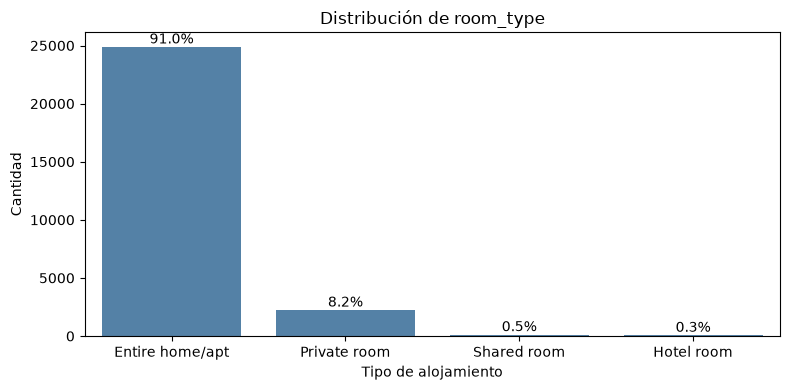

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='room_type', order=df['room_type'].value_counts().index, color='steelblue')

# Mostramos el porcentaje sobre cada barra ya que "Shared room" y "Hotel room" tienen muy pocos
total = len(df)
ax = plt.gca()
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Distribución de room_type')
plt.xlabel('Tipo de alojamiento')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()


La variable *neighbourhood* tiene altísima cardinalidad, por lo que para visualizarla mediante barras se realizó lo siguiente:
- Se redujeron las categorías a graficar a las 15 más frecuentes.
- Se agruparon las categorías restantes en una categoría "Otros".
- Se graficó horizontalmente para mejorar la legibilidad (los barrios generalmente tienen nombres largos dificiles de leer en el eje de abscisas).

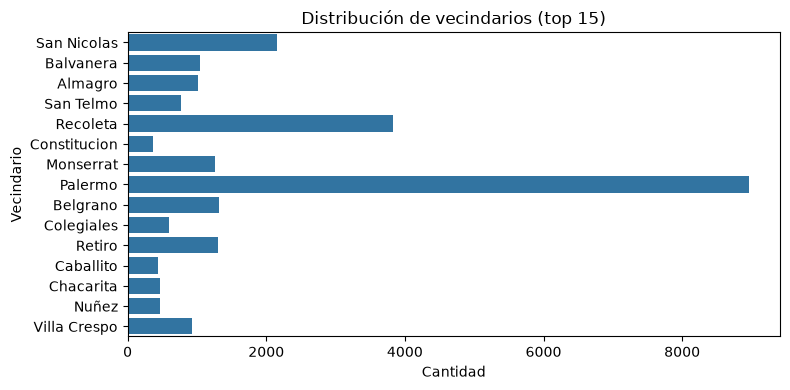

In [36]:
plt.figure(figsize=(8, 4))

top_n = df['neighbourhood'].value_counts().head(15).index
sns.countplot(data=df[df['neighbourhood'].isin(top_n)], y='neighbourhood')

plt.title('Distribución de vecindarios (top 15)')
plt.xlabel('Cantidad')
plt.ylabel('Vecindario')
plt.tight_layout()
plt.show()

Las variables *latitude* y *longitude* se pueden visualizar conjuntamente mediante un gráfico de dispersión, para tratar de observar la distribución geográfica de los alojamientos.

Se observa la gran dominancia de los alojamientos del tipo apartamento completo. Resulta muy interesante que el gráfico de dispersión da la silueta de la Ciudad de Buenos Aires.

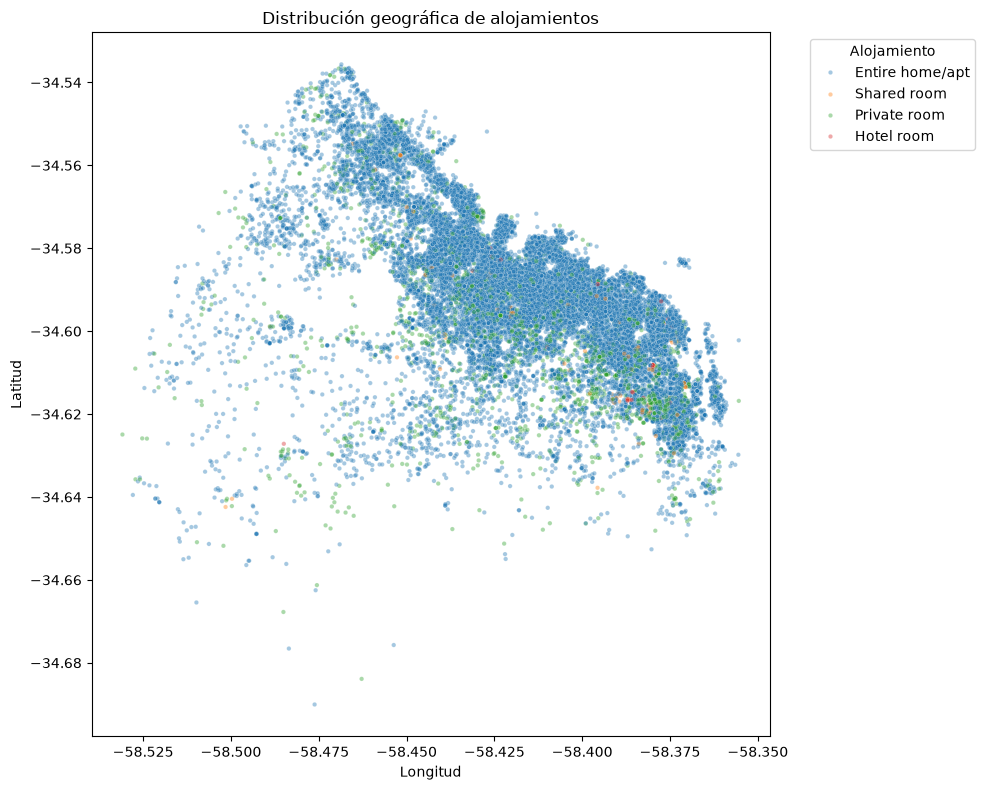

In [37]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='room_type', alpha=0.4, s=10)

plt.title('Distribución geográfica de alojamientos')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Alojamiento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Para probar la hipótesis de que este gráfico de dispersión tiene implícita la silueta de la Ciudad de Buenos Aires, se puede superponer el gráfico de dispersión con un mapa de la ciudad. De esta forma se puede verificar si los puntos del gráfico de dispersión coinciden con las zonas geográficas y barrios de la ciudad.

In [38]:
# import contextily as ctx
# from pyproj import Transformer

# # Reproyectar a Web Mercator (que usa contextily)
# transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
# x, y = transformer.transform(df['longitude'].values, df['latitude'].values)
# df_merc = df.assign(x=x, y=y)

# fig, ax = plt.subplots(figsize=(10, 8))
# sns.scatterplot(data=df_merc, x='x', y='y', hue='room_type', alpha=0.4, s=10, ax=ax)
# ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
# ax.set_axis_off()
# plt.tight_layout()
# plt.show()


# 3. Plantear un posible problema de ML supervisado a partir de los datos elegidos

A partir de los datos explorados, planteamos un problema de **regresión** cuya variable objetivo (*target*) es **`number_of_reviews`**: predecir la cantidad de reseñas que acumula un alojamiento en función de sus características (tipo de alojamiento, ubicación, disponibilidad, noches mínimas, etc.). Esta variable funciona como un *proxy de la popularidad/demanda* del listado. Es un problema de regresión porque el target es numérico.

Elegimos este target por dos motivos: está **completo** (sin valores nulos en las 27.348 observaciones), lo que permite entrenar y evaluar el modelo; y resulta de interés práctico estimar qué tan demandado será un alojamiento.

**¿Por qué no el precio?** El target más natural para este dataset hubiera sido el **precio** de alquiler. Sin embargo, en este snapshot la variable `price` está **100% nula** (faltante en todas las observaciones). Un modelo supervisado necesita ejemplos etiquetados con valores reales del target: sin un solo valor de `price` no hay datos de los cuales aprender (*train*) ni con qué comparar las predicciones (*test*), por lo que es inviable como objetivo. Tampoco corresponde imputar el target (se estaría inventando la respuesta a predecir) ni fabricarlo con una heurística a partir de las mismas features (sería circular). Por eso descartamos el precio y adoptamos `number_of_reviews`.

Para que el planteo sea válido, en el preprocesamiento (sección 4) se eliminan las variables que filtrarían información del target (*data leakage*), como `number_of_reviews_ltm`.

# 4. Preprocesamiento y limpieza del dataset

- Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.
- Realizar el split del dataset (ej: train y test).
- Identificar y tratar los valores faltantes en el dataset.
- Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.
- Escalar/normalizar los features.

## 4.1. Limpieza general del dataset

Eliminamos las columnas que no aportan valor predictivo o que presentan una cantidad excesiva de valores faltantes:

- `id`, `host_id`, `host_profile_id`: son identificadores únicos sin poder predictivo.
- `name`, `host_name`: texto libre de altísima cardinalidad; requeriría procesamiento de NLP complejo para extraer señal útil y no justifica el esfuerzo en este contexto.
- `neighbourhood_group`: 100% valores nulos, columna vacía sin información.
- `price`: 100% valores nulos. En la sección 3 se había propuesto predecir el precio, pero al estar totalmente ausente descartamos este target y elegimos `number_of_reviews`.
- `license`: ~98% valores nulos, columna prácticamente vacía.

También eliminamos `number_of_reviews_ltm` para evitar **data leakage**: esta columna (reseñas del último mes) está intrínsecamente correlacionada con el target `number_of_reviews` (reseñas totales), ya que esta última es la acumulación histórica que incluye el último mes. Incluirla como feature daría al modelo información del futuro (o duplicada) al momento de predecir.

Las columnas que conservamos son las que realmente describen características del alojamiento sin depender del target.


In [39]:
# --- 4.1. Limpieza general ---

cols_a_eliminar = [
    'id',                     # identificador sin valor predictivo
    'host_id',                # identificador
    'host_profile_id',        # identificador
    'name',                   # texto libre de alta cardinalidad
    'host_name',              # texto libre
    'neighbourhood_group',    # 100% NaN
    'price',                  # 100% NaN
    'license',                # ~98% NaN
    'number_of_reviews_ltm',  # data leakage con el target
]

# Verificar nulos antes de eliminar (confirmación)
print("Nulos antes de limpieza:")
print(df[cols_a_eliminar].isnull().sum())

df_clean = df.drop(columns=cols_a_eliminar)

print(f"\nDimensiones tras limpieza: {df_clean.shape}")
print(f"Columnas restantes: {df_clean.columns.tolist()}")


Nulos antes de limpieza:
id                           0
host_id                      0
host_profile_id              0
name                         0
host_name                    0
neighbourhood_group      27348
price                    27348
license                  26887
number_of_reviews_ltm        0
dtype: int64

Dimensiones tras limpieza: (27348, 10)
Columnas restantes: ['neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


## 4.2. Tratamiento de valores faltantes

Identificamos las columnas con valores nulos y analizamos el mecanismo de missingness antes de imputar.

**`minimum_nights` (106 nulos):** 
- Mecanismo: MAR (Missing At Random), la ausencia probablemente se debe a errores de carga del dato.
- Imputamos con la **mediana** (2.0), que es robusta ante outliers y representa el valor típico de estadía mínima en CABA.

**`reviews_per_month` y `last_review` (3303 nulos cada una, exactamente los mismos registros):**
- Son los mismos 3303 listings con `number_of_reviews = 0`. Si un alojamiento nunca recibió reseñas, lógicamente no tiene `last_review` ni `reviews_per_month`.
- Mecanismo: Es una ausencia estructural, ya que se explica completamente por `number_of_reviews = 0`, una variable observada.

**`reviews_per_month`:** imputamos con **0**, que es el valor real (si hay 0 reseñas, la tasa mensual es 0).

**`last_review`:** la transformamos a una variable numérica `last_review_days` = días transcurridos entre la fecha de la última reseña y la fecha máxima del dataset (2026-01-25). Para los registros sin reseña, imputamos con el rango total del dataset (`max_date - min_date = 4767` días), representando que "nunca tuvo reseña", el máximo tiempo posible dentro de la ventana de datos.

**Nota sobre data leakage:** la imputación y la transformación logarítmica (4.3) se aplican sobre el dataset completo, antes del split train/test. Esto es técnicamente data leakage, pero el impacto práctico es despreciable: la mediana de `minimum_nights` y el rango de fechas apenas varían entre train y test con 27 k muestras. Se opta por este orden por simplicidad, ya que la transformación logarítmica también se aplica pre-split y mantener todo junto sin depender del split evita complejidades innecesarias.


In [40]:
# --- 4.2. Tratamiento de valores faltantes ---

# --- minimum_nights: imputar con mediana ---
median_min_nights = df_clean['minimum_nights'].median()
print(f"Mediana de minimum_nights: {median_min_nights}")

df_clean['minimum_nights'] = df_clean['minimum_nights'].fillna(median_min_nights)
print(f"Nulos restantes en minimum_nights: {df_clean['minimum_nights'].isnull().sum()}")

# --- reviews_per_month: imputar con 0 (sin reseñas → 0 reseñas/mes) ---
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)
print(f"Nulos restantes en reviews_per_month: {df_clean['reviews_per_month'].isnull().sum()}")

# --- last_review: convertir a días desde la última reseña ---
# Fecha de referencia: fecha máxima del dataset
fechas = pandas.to_datetime(df_clean['last_review'], errors='coerce')
fecha_max = fechas.max()
fecha_min = fechas.min()
print(f"Rango temporal: {fecha_min} a {fecha_max}")
print(f"Días totales del rango: {(fecha_max - fecha_min).days}")

# Calcular días desde la última reseña hasta la fecha máxima
df_clean['last_review_days'] = (fecha_max - fechas).dt.days

# Imputar NaN con el rango total (máximo tiempo posible = nunca tuvo reseña)
dias_rango = (fecha_max - fecha_min).days
df_clean['last_review_days'] = df_clean['last_review_days'].fillna(dias_rango)

print(f"Nulos restantes en last_review_days: {df_clean['last_review_days'].isnull().sum()}")
print(f"Estadísticas de last_review_days:\n{df_clean['last_review_days'].describe()}")

# Eliminar columna original last_review (ya no la necesitamos como fecha)
df_clean = df_clean.drop(columns=['last_review'])

# Verificar que no queden nulos
print(f"\nNulos totales restantes: {df_clean.isnull().sum().sum()}")


Mediana de minimum_nights: 2.0
Nulos restantes en minimum_nights: 0
Nulos restantes en reviews_per_month: 0
Rango temporal: 2013-01-06 00:00:00 a 2026-01-25 00:00:00
Días totales del rango: 4767
Nulos restantes en last_review_days: 0
Estadísticas de last_review_days:
count    27348.000000
mean       730.775011
std       1543.803032
min          0.000000
25%         18.000000
50%         44.000000
75%        307.000000
max       4767.000000
Name: last_review_days, dtype: float64

Nulos totales restantes: 0


## 4.3. Transformación de variables asimétricas (outliers)

En lugar de descartar outliers, aplicamos transformación **log(1+x)** a las variables numéricas con distribución asimétrica positiva (skewness). Esto comprime la cola larga, reduce la influencia de valores extremos y hace que la distribución se aproxime más a una gaussiana, beneficiando a modelos lineales.

Las columnas transformadas comparten una característica: son **variables de conteo o ratio** cuyos valores pueden diferir en órdenes de magnitud:

| Columna | Rango | Descripción |
|---|---|---|
| `minimum_nights` | 1 – 730 | algunos listings exigen estadías muy largas |
| `number_of_reviews` (target) | 0 – 1044 | algunos son muy populares |
| `reviews_per_month` | 0 – 28.69 | concentración en valores bajos |
| `calculated_host_listings_count` | 1 – 188 | pocos hosts con muchos listings |

No transformamos `latitude`, `longitude` ni `availability_365` porque ya presentan distribuciones aproximadamente simétricas y rangos acotados sin outliers significativos.


Antes de transformar, detectamos outliers mediante el rango intercuartil (IQR) para confirmar la presencia de valores extremos en estas 4 variables.


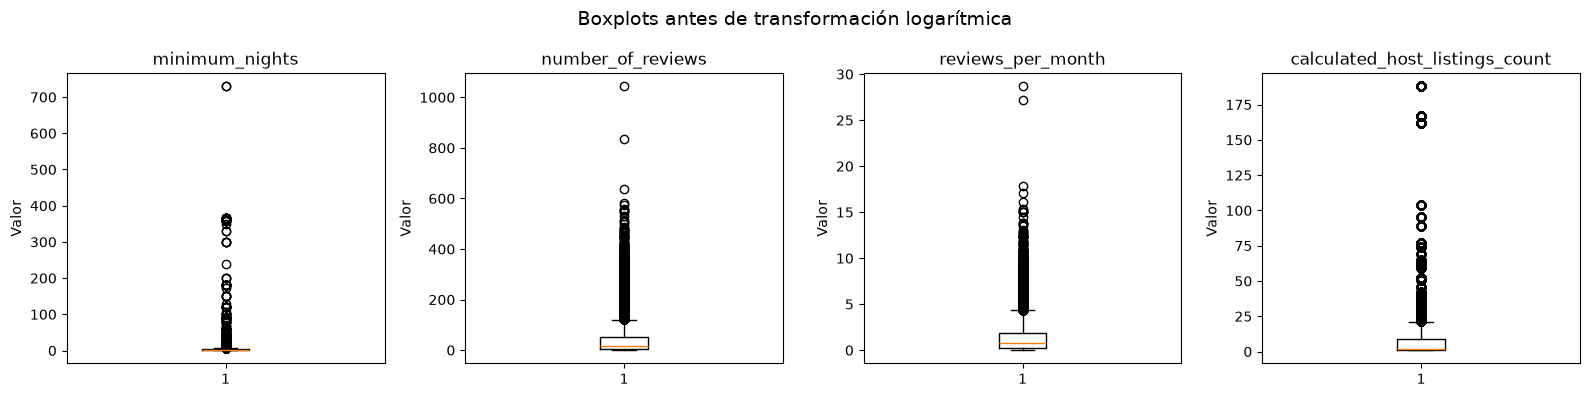

Outliers detectados por IQR (k=1.5):
  minimum_nights                             3012 outliers  (11.0%)
  number_of_reviews                          1973 outliers  (7.2%)
  reviews_per_month                          1177 outliers  (4.3%)
  calculated_host_listings_count             4074 outliers  (14.9%)


In [41]:
# --- 4.3. Detección de outliers (IQR) antes de transformar ---

cols_outlier = ['minimum_nights', 'number_of_reviews',
                'reviews_per_month', 'calculated_host_listings_count']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cols_outlier):
    ax.boxplot(df_clean[col])
    ax.set_title(col)
    ax.set_ylabel('Valor')
plt.suptitle('Boxplots antes de transformación logarítmica', fontsize=14)
plt.tight_layout()
plt.show()

# Conteo de outliers por IQR
print("Outliers detectados por IQR (k=1.5):")
for col in cols_outlier:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_outliers = ((df_clean[col] < lim_inf) | (df_clean[col] > lim_sup)).sum()
    print(f"  {col:40s}  {n_outliers:>5d} outliers  ({n_outliers/len(df_clean)*100:.1f}%)")


In [42]:
# --- 4.3. Transformación logarítmica de variables asimétricas ---

import numpy as np

cols_a_transformar = [
    'minimum_nights',
    'number_of_reviews',              # target
    'reviews_per_month',
    'calculated_host_listings_count',
]

for col in cols_a_transformar:
    # Mostrar skewness antes
    skew_before = df_clean[col].skew()
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])
    skew_after = df_clean[f'{col}_log'].skew()
    print(f"{col:40s}  skew antes: {skew_before:8.3f}  |  skew después: {skew_after:8.3f}")

    # Eliminar columna original (nos quedamos con la versión log)
    df_clean = df_clean.drop(columns=[col])

# Renombrar las columnas log para que quede más limpio
rename_map = {f'{col}_log': col for col in cols_a_transformar}
df_clean = df_clean.rename(columns=rename_map)

print(f"\nColumnas finales: {df_clean.columns.tolist()}")


minimum_nights                            skew antes:   18.304  |  skew después:    2.233
number_of_reviews                         skew antes:    3.278  |  skew después:   -0.239
reviews_per_month                         skew antes:    2.775  |  skew después:    0.653
calculated_host_listings_count            skew antes:    4.204  |  skew después:    1.188

Columnas finales: ['neighbourhood', 'latitude', 'longitude', 'room_type', 'availability_365', 'last_review_days', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count']


## 4.4. Split del dataset (train / test)

Separamos el dataset en entrenamiento (80%) y prueba (20%).

**Cambio de target:** originalmente se planteó predecir `price`, pero al estar 100% nulo redirigimos el problema a predecir `number_of_reviews` (regresión). Esta variable mide la popularidad del alojamiento y está completa, sin valores nulos.

**Data leakage:** eliminamos `number_of_reviews_ltm` (reseñas del último mes) porque está directamente contenida dentro del target `number_of_reviews` (reseñas totales). Incluirla como feature permitiría al modelo "hacer trampa" prediciendo basándose en una parte del propio target.

Realizamos el split con `random_state=42` para garantizar reproducibilidad.

**Estratificación:** idealmente estratificaríamos por `neighbourhood` para asegurar representación proporcional de cada barrio en train y test. Sin embargo, esta variable tiene alta cardinalidad con barrios de muy baja frecuencia, lo que requiere agrupar categorías antes de estratificar. El split definitivo se realizará en la sección 5.3, luego de codificar las variables categóricas.


## 4.5. Escalado de features numéricas

Aplicamos `StandardScaler` (centrado y escalado a media 0, varianza 1) sobre las features numéricas. Esto es necesario para modelos sensibles a la escala de las variables (como regresión lineal, SVM, KNN, etc.).

El escalado se realizará en la sección 5.3, junto con el split estratificado, sobre el dataset ya codificado y dividido en train/test.


# 5. Feature engineering

- Crear nuevos features en caso de ser necesario. Justificar.
- Aplicar técnicas de conversión de variables: codificación, discretización.
- Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).
- Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

A continuación desarrollamos cada punto en el contexto de nuestro problema de regresión sobre `number_of_reviews`.


## 5.1. Codificación de variables categóricas

**`room_type`:** Aplicamos one-hot encoding. No tiene un orden natural inequívoco (los 4 tipos, Entire home/apt, Private room, Shared room, Hotel room, son cualitativamente distintos), por lo que one-hot es la opción más segura.

**`neighbourhood`:** Tiene alta cardinalidad (~40 barrios) con una cola larga de barrios muy poco frecuentes. Aplicamos one-hot encoding pero **agrupando primero** los barrios con menos de 200 listings en una categoría "Otros". Esto evita crear columnas con casi todo ceros (datos dispersos) y permite además estratificar el split por barrio.

El umbral de 200 se eligió analizando el tradeoff entre cantidad de columnas one-hot y cobertura: con 200 quedan 18 barrios individuales y "Otros" contiene solo el ~5.6% de los listings. Los rankings de relevancia en la sección 6.1 confirman que los barrios por debajo de este umbral tienen baja señal predictiva.


In [43]:
# --- 5.1. Codificación de variables categóricas ---

import pandas as pd

# --- Agrupar neighbourhood de baja frecuencia ---
umbral = 200
freq = df_clean['neighbourhood'].value_counts()
barrios_raros = freq[freq < umbral].index

df_clean['neighbourhood_grouped'] = df_clean['neighbourhood'].copy()
df_clean.loc[df_clean['neighbourhood_grouped'].isin(barrios_raros), 'neighbourhood_grouped'] = 'Otros'

print(f"Barrios originales: {df_clean['neighbourhood'].nunique()}")
print(f"Barrios agrupados:  {df_clean['neighbourhood_grouped'].nunique()}")
print(f"Agrupados como 'Otros': {len(barrios_raros)} barrios con <{umbral} listings")
print(f"\nDistribución de neighbourhood_grouped:")
print(df_clean['neighbourhood_grouped'].value_counts().head(20))

# --- Guardar columna de estratificación antes del encoding ---
# (pd.get_dummies elimina la columna original al reemplazarla por one-hot)
strat_labels = df_clean['neighbourhood_grouped'].copy()

# --- Eliminar neighbourhood original (ya tenemos la versión agrupada) ---
df_clean = df_clean.drop(columns=['neighbourhood'])

# --- One-hot encoding ---
cat_cols = ['room_type', 'neighbourhood_grouped']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dtype=int)

# Verificar resultado
encoded_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print(f"\nColumnas one-hot creadas ({len(encoded_cols)}): {encoded_cols}")
print(f"Dimensiones: {df_encoded.shape}")

Barrios originales: 48
Barrios agrupados:  19
Agrupados como 'Otros': 30 barrios con <200 listings

Distribución de neighbourhood_grouped:
neighbourhood_grouped
Palermo          8963
Recoleta         3828
San Nicolas      2156
Otros            1533
Belgrano         1318
Retiro           1310
Monserrat        1256
Balvanera        1051
Almagro          1011
Villa Crespo      927
San Telmo         769
Colegiales        604
Chacarita         473
Nuñez             473
Caballito         443
Constitucion      372
Puerto Madero     361
Villa Urquiza     299
Barracas          201
Name: count, dtype: int64

Columnas one-hot creadas (21): ['room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_grouped_Balvanera', 'neighbourhood_grouped_Barracas', 'neighbourhood_grouped_Belgrano', 'neighbourhood_grouped_Caballito', 'neighbourhood_grouped_Chacarita', 'neighbourhood_grouped_Colegiales', 'neighbourhood_grouped_Constitucion', 'neighbourhood_grouped_Monserrat', 'neig

## 5.2. Creación de nuevos features

El único feature creado es `neighbourhood_grouped`, que ya se incorporó en el paso anterior. No agregamos más features: contamos con coordenadas geográficas, disponibilidad, días desde la última reseña, noches mínimas, reseñas por mes y cantidad de listings del host. Consideramos que este conjunto captura adecuadamente las características del alojamiento para predecir el número de reseñas.

Nota: el feature `last_review_days` se creó en la sección 4.2.


## 5.3. Split estratificado y escalado

Rehacemos el split utilizando `stratify=neighbourhood_grouped` (la versión agrupada), asegurando que cada grupo de barrio esté representado proporcionalmente en train y test. Luego aplicamos `StandardScaler` sobre las columnas numéricas.

El target sigue siendo `number_of_reviews` (transformado con log(1+x) en la sección 4.3).


In [44]:
# --- 5.3. Split estratificado y escalado ---

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features y target
target_col = 'number_of_reviews'
feature_cols = [c for c in df_encoded.columns if c != target_col]
strat_col = 'neighbourhood_grouped'

X = df_encoded[feature_cols]
y = df_encoded[target_col]

# Split estratificado por neighbourhood_grouped
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=strat_labels  # columna guardada antes del one-hot (5.1)
)

print(f"Split estratificado por {strat_col}")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

# Verificar proporciones
train_strat = X_train.filter(like='neighbourhood_grouped_').sum()
test_strat = X_test.filter(like='neighbourhood_grouped_').sum()
if len(train_strat) > 0:
    print(f"\nProporción por barrio (train vs test):")
    for col in train_strat.index:
        barrio = col.replace('neighbourhood_grouped_', '')
        p_train = train_strat[col] / X_train.shape[0] * 100
        p_test = test_strat[col] / X_test.shape[0] * 100
        print(f"  {barrio:25s}  train: {p_train:5.1f}%  test: {p_test:5.1f}%")

# --- Escalado ---
cols_numericas = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Excluir columnas one-hot (binarias, no se escalan)
cols_numericas = [c for c in cols_numericas if not c.startswith(('room_type_', 'neighbourhood_grouped_'))]

print(f"\nNuméricas a escalar ({len(cols_numericas)}): {cols_numericas}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols_numericas] = scaler.fit_transform(X_train[cols_numericas])
X_test_scaled[cols_numericas] = scaler.transform(X_test[cols_numericas])

print(f"Medias (train, escaladas):\n{X_train_scaled[cols_numericas].mean().round(4)}")
print(f"\nDesvíos (train, escaladas):\n{X_train_scaled[cols_numericas].std().round(4)}")

Split estratificado por neighbourhood_grouped
Train: 21878 muestras
Test:  5470 muestras

Proporción por barrio (train vs test):
  Balvanera                  train:   3.8%  test:   3.8%
  Barracas                   train:   0.7%  test:   0.7%
  Belgrano                   train:   4.8%  test:   4.8%
  Caballito                  train:   1.6%  test:   1.6%
  Chacarita                  train:   1.7%  test:   1.7%
  Colegiales                 train:   2.2%  test:   2.2%
  Constitucion               train:   1.4%  test:   1.4%
  Monserrat                  train:   4.6%  test:   4.6%
  Nuñez                      train:   1.7%  test:   1.7%
  Otros                      train:   5.6%  test:   5.6%
  Palermo                    train:  32.8%  test:  32.8%
  Puerto Madero              train:   1.3%  test:   1.3%
  Recoleta                   train:  14.0%  test:  14.0%
  Retiro                     train:   4.8%  test:   4.8%
  San Nicolas                train:   7.9%  test:   7.9%
  San Telmo     

## 5.4. Análisis de balance/desbalance y mecanismos de balance

**"Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación)"**
> Nuestro problema es de **regresión** (predecir `number_of_reviews`), no de clasificación. Por lo tanto el concepto de "balance de clases" no aplica al target.

**"Proponer y aplicar mecanismos de balance en caso de ser necesario"**
> Al no tratarse de un problema de clasificación, no corresponde aplicar oversampling, undersampling ni técnicas similares.

No obstante, analizamos la distribución del target y la frecuencia de las categorías resultantes de la codificación:


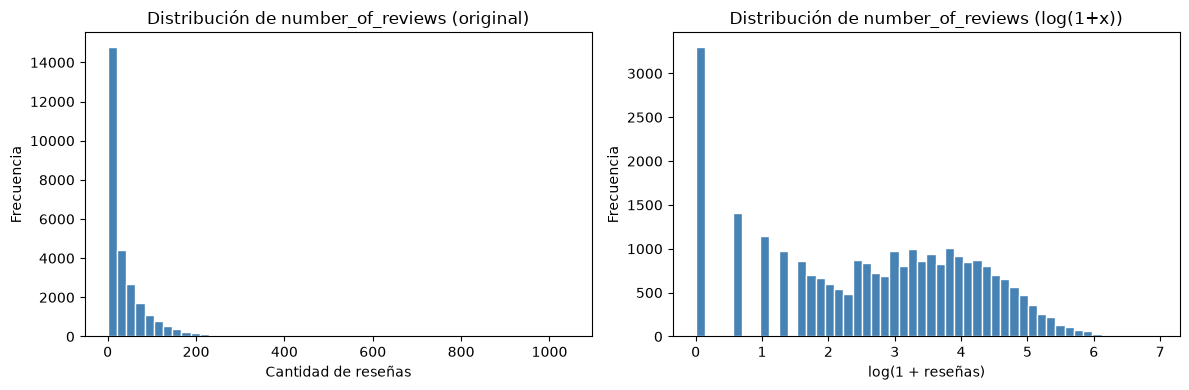

Estadísticas del target (original):
count    27348.000000
mean        38.127176
std         56.082583
min          0.000000
25%          4.000000
50%         17.000000
75%         51.000000
max       1044.000000

Estadísticas del target (log):
count    27348.000000
mean         2.695777
std          1.565949
min          0.000000
25%          1.609438
50%          2.890372
75%          3.951244
max          6.951772

--- Balance de neighbourhood_grouped ---
                       Cantidad  Porcentaje
neighbourhood_grouped                      
Palermo                    8963        32.8
Recoleta                   3828        14.0
San Nicolas                2156         7.9
Otros                      1533         5.6
Belgrano                   1318         4.8
Retiro                     1310         4.8
Monserrat                  1256         4.6
Balvanera                  1051         3.8
Almagro                    1011         3.7
Villa Crespo                927         3.4
San Telmo 

In [45]:
# --- 5.4. Análisis de distribución y balance ---

import matplotlib.pyplot as plt

# --- Distribución del target (escala original vs log) ---
y_original_approx = np.expm1(y)  # inversa de log(1+x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_original_approx, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de number_of_reviews (original)')
axes[0].set_xlabel('Cantidad de reseñas')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de number_of_reviews (log(1+x))')
axes[1].set_xlabel('log(1 + reseñas)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print(f"Estadísticas del target (original):")
print(y_original_approx.describe().to_string())
print(f"\nEstadísticas del target (log):")
print(y.describe().to_string())

# --- Balance de neighbourhood_grouped ---
print(f"\n--- Balance de neighbourhood_grouped ---")
nh_counts = df_clean['neighbourhood_grouped'].value_counts()
nh_pct = df_clean['neighbourhood_grouped'].value_counts(normalize=True) * 100
balance_nh = pd.DataFrame({'Cantidad': nh_counts, 'Porcentaje': nh_pct.round(1)})
print(balance_nh.to_string())

# --- Balance de room_type ---
print(f"\n--- Balance de room_type ---")
rt_counts = df_clean['room_type'].value_counts()
rt_pct = df_clean['room_type'].value_counts(normalize=True) * 100
balance_rt = pd.DataFrame({'Cantidad': rt_counts, 'Porcentaje': rt_pct.round(1)})
print(balance_rt.to_string())

# 6. Reducción de dimensionalidad

- Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros, información mutua, CHI2, ANOVA, etc.).
- Implementar la técnica de extracción de features vista en clase (PCA). Evaluar ventajas y desventajas de la reducción.

A continuación desarrollamos cada punto.


## 6.1. Selección de features con filtros

Aplicamos tres técnicas de filtro sobre el conjunto de entrenamiento para evaluar la relevancia de cada feature respecto del target `number_of_reviews`:

### Correlación de Pearson
Mide la relación lineal entre cada feature numérica y el target. También detectamos pares de features con alta correlación entre sí (multicolinealidad).

### ANOVA F-test (`f_regression`)
Ajusta una regresión lineal simple de cada feature contra el target y calcula el estadístico F = varianza explicada / varianza residual. Un F alto indica que la feature tiene una relación lineal significativa con el target.

### Mutual Information (`mutual_info_regression`)
Mide la dependencia entre cada feature y el target sin asumir linealidad, capturando relaciones no lineales que el F-test podría pasar por alto.

### CHI2
No corresponde: requiere features no-negativas y target categórico. Nuestro target es continuo (regresión), por lo que no aplicamos esta prueba.

### Conclusión
Comparamos los rankings de F-test y Mutual Information para decidir qué features conservar.


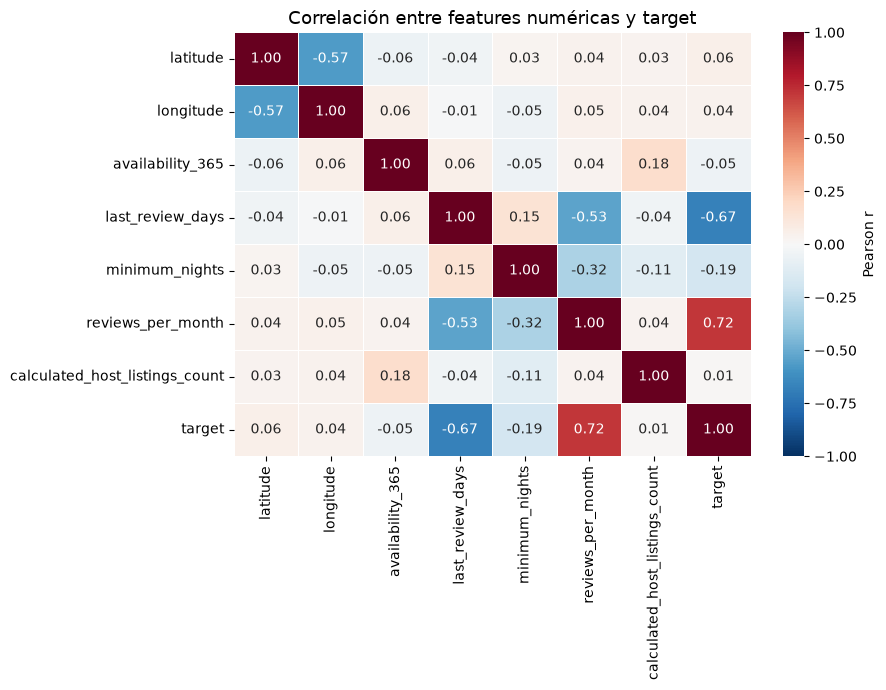

Correlación de cada feature numérica con el target (Pearson):
reviews_per_month                 0.7165
latitude                          0.0551
longitude                         0.0395
calculated_host_listings_count    0.0085
availability_365                 -0.0511
minimum_nights                   -0.1872
last_review_days                 -0.6719

Pares de features numéricas con alta correlación (|r| > 0.8):
  (ningún par supera el umbral de 0.8)

Ranking por ANOVA F-test (f_regression):
                            feature  F_statistic  p_value
                  reviews_per_month   23082.4014   0.0000
                   last_review_days   18007.7240   0.0000
                     minimum_nights     794.1271   0.0000
             room_type_Private room     416.0710   0.0000
      neighbourhood_grouped_Palermo     328.0211   0.0000
        neighbourhood_grouped_Otros     206.5688   0.0000
               room_type_Hotel room     110.8057   0.0000
    neighbourhood_grouped_Balvanera      89

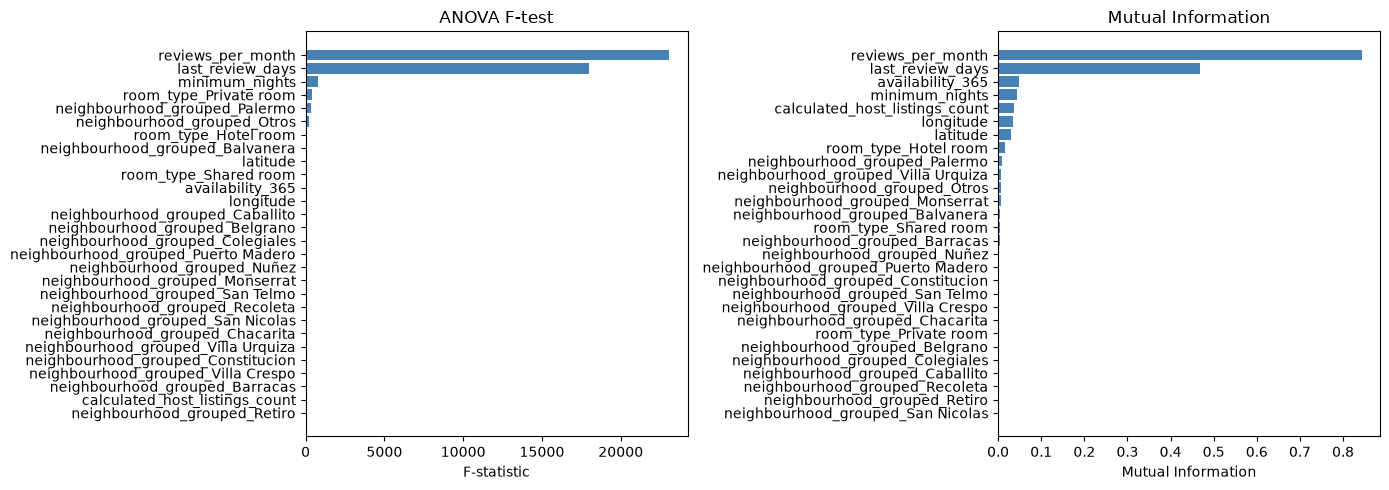

In [46]:
# --- 6.1. Selección de features con filtros ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression, mutual_info_regression

# --- 1. Matriz de correlación (features numéricas + target) ---
# Excluimos las one-hot porque su correlación individual con el target es baja
num_cols_hm = ['latitude', 'longitude', 'availability_365',
               'last_review_days', 'minimum_nights',
               'reviews_per_month', 'calculated_host_listings_count', 'target']

corr_hm = X_train_scaled[num_cols_hm[:-1]].copy()
corr_hm['target'] = y_train
corr_matrix = corr_hm.corr(method='pearson')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'label': 'Pearson r'})
plt.title('Correlación entre features numéricas y target', fontsize=13)
plt.tight_layout()
plt.show()

# Correlación con el target
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)
print("Correlación de cada feature numérica con el target (Pearson):")
print(target_corr.to_string(float_format=lambda x: f'{x:.4f}'))

# Multicolinealidad: pares con |r| > 0.8 entre features numéricas
print("\nPares de features numéricas con alta correlación (|r| > 0.8):")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        if col_i == 'target' or col_j == 'target':
            continue
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((col_i, col_j, r))
            print(f"  {col_i:40s}  vs  {col_j:40s}  r = {r:.3f}")
if not high_corr:
    print("  (ningún par supera el umbral de 0.8)")

# --- 2. ANOVA F-test ---
f_stats, p_values = f_regression(X_train_scaled, y_train)

ranking_f = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'F_statistic': f_stats,
    'p_value': p_values
}).sort_values('F_statistic', ascending=False).reset_index(drop=True)

print("\nRanking por ANOVA F-test (f_regression):")
print(ranking_f.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# --- 3. Mutual Information ---
mi = mutual_info_regression(X_train_scaled, y_train, random_state=42)

ranking_mi = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'mutual_info': mi
}).sort_values('mutual_info', ascending=False).reset_index(drop=True)

print("\nRanking por Mutual Information:")
print(ranking_mi.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# --- 4. Comparativa ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(len(ranking_f)), ranking_f['F_statistic'][::-1], color='steelblue')
axes[0].set_yticks(range(len(ranking_f)))
axes[0].set_yticklabels(ranking_f['feature'][::-1])
axes[0].set_xlabel('F-statistic')
axes[0].set_title('ANOVA F-test')

axes[1].barh(range(len(ranking_mi)), ranking_mi['mutual_info'][::-1], color='steelblue')
axes[1].set_yticks(range(len(ranking_mi)))
axes[1].set_yticklabels(ranking_mi['feature'][::-1])
axes[1].set_xlabel('Mutual Information')
axes[1].set_title('Mutual Information')

plt.tight_layout()
plt.show()

### Importancia por grupo de features

Las columnas one-hot de una misma variable original dividen su importancia entre múltiples columnas, lo que subestima su relevancia en los rankings individuales. Agrupamos las one-hot por variable original y reportamos la suma de F-statistic y el promedio de Mutual Information por grupo.


In [47]:
# --- 6.1. Importancia por grupo de features ---

# Definir grupos: columnas que comparten prefijo (one-hot) o son individuales (numéricas)
feature_cols = ranking_f['feature'].tolist()

grupos = {}
for col in feature_cols:
    # Detectar prefijo de one-hot
    if col.startswith('room_type_'):
        grupo = 'room_type'
    elif col.startswith('neighbourhood_grouped_'):
        grupo = 'neighbourhood_grouped'
    else:
        grupo = col  # numérica individual
    if grupo not in grupos:
        grupos[grupo] = []
    grupos[grupo].append(col)

filas = []
for grupo, cols in grupos.items():
    f_total = ranking_f[ranking_f['feature'].isin(cols)]['F_statistic'].sum()
    mi_prom = ranking_mi[ranking_mi['feature'].isin(cols)]['mutual_info'].mean()
    filas.append({'feature_group': grupo, 'F_total': f_total, 'MI_promedio': mi_prom})

ranking_grupo = pd.DataFrame(filas).sort_values('F_total', ascending=False).reset_index(drop=True)

print("Importancia por grupo de features:")
print(ranking_grupo.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


Importancia por grupo de features:
                 feature_group    F_total  MI_promedio
             reviews_per_month 23082.4014       0.8435
              last_review_days 18007.7240       0.4679
                minimum_nights   794.1271       0.0440
         neighbourhood_grouped   754.5042       0.0030
                     room_type   591.7458       0.0073
                      latitude    66.5305       0.0305
              availability_365    57.3282       0.0495
                     longitude    34.1264       0.0341
calculated_host_listings_count     1.5654       0.0363


## 6.2. PCA (Principal Component Analysis)

Aplicamos PCA sobre las **7 features numéricas continuas** (latitude, longitude, availability_365, last_review_days, minimum_nights, reviews_per_month, calculated_host_listings_count).

Las columnas one-hot (`room_type_*`, `neighbourhood_grouped_*`) se excluyen porque PCA sobre variables binarias no es adecuado: la distancia euclídea que usa PCA presupone datos continuos, y las one-hot son categóricas sin relación métrica entre sí.

Evaluamos cuánta varianza explica cada componente y discutimos ventajas y desventajas de la reducción.


Numéricas para PCA (7): ['latitude', 'longitude', 'availability_365', 'last_review_days', 'minimum_nights', 'reviews_per_month', 'calculated_host_listings_count']
One-hot (excluidas de PCA, 21): ['room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_grouped_Balvanera', 'neighbourhood_grouped_Barracas', 'neighbourhood_grouped_Belgrano', 'neighbourhood_grouped_Caballito', 'neighbourhood_grouped_Chacarita', 'neighbourhood_grouped_Colegiales', 'neighbourhood_grouped_Constitucion', 'neighbourhood_grouped_Monserrat', 'neighbourhood_grouped_Nuñez', 'neighbourhood_grouped_Otros', 'neighbourhood_grouped_Palermo', 'neighbourhood_grouped_Puerto Madero', 'neighbourhood_grouped_Recoleta', 'neighbourhood_grouped_Retiro', 'neighbourhood_grouped_San Nicolas', 'neighbourhood_grouped_San Telmo', 'neighbourhood_grouped_Villa Crespo', 'neighbourhood_grouped_Villa Urquiza']

Varianza explicada por componente:
  PC1: 0.2450 (24.5%)  |  acumulado: 0.2450 (24.5%)
  PC2: 0.2

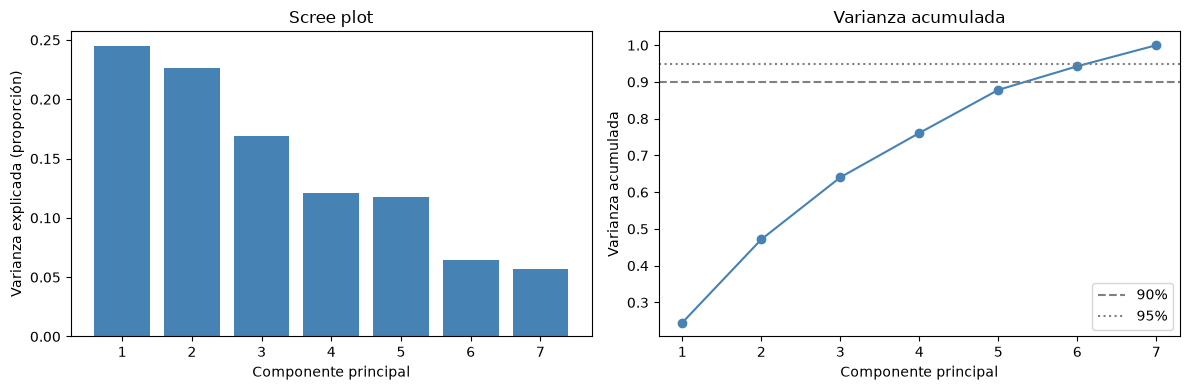


Loadings (contribución de cada feature a los PC 1-5):
                                   PC1     PC2     PC3     PC4     PC5
latitude                       -0.0612  0.6903  0.1554  0.0038 -0.0026
longitude                       0.1485 -0.6776 -0.1068  0.0271  0.1221
availability_365                0.0746 -0.1588  0.6544  0.4491 -0.5718
last_review_days               -0.5731 -0.1554  0.2274 -0.3940 -0.2011
minimum_nights                 -0.4469  0.0059 -0.1648  0.7820  0.3179
reviews_per_month               0.6441  0.1158 -0.1141  0.1549 -0.0976
calculated_host_listings_count  0.1601 -0.0394  0.6665 -0.0832  0.7121

Componentes necesarios para 90% de varianza: 6
Componentes necesarios para 95% de varianza: 7

Dimensiones originales: 28 features
Dimensiones reducidas:  27 features (6 PCs + 21 one-hot)


In [48]:
# --- 6.2. PCA sobre features numéricas ---

from sklearn.decomposition import PCA

# Columnas numéricas continuas (excluyendo one-hot)
num_cols = [
    'latitude', 'longitude', 'availability_365',
    'last_review_days', 'minimum_nights',
    'reviews_per_month', 'calculated_host_listings_count',
]

onehot_cols = [c for c in X_train_scaled.columns if c not in num_cols]
print(f"Numéricas para PCA ({len(num_cols)}): {num_cols}")
print(f"One-hot (excluidas de PCA, {len(onehot_cols)}): {onehot_cols}")

# Ajustar PCA
pca = PCA()
pca.fit(X_train_scaled[num_cols])

# Varianza explicada
expl_var = pca.explained_variance_ratio_
cum_var = expl_var.cumsum()

print(f"\nVarianza explicada por componente:")
for i, (ev, cv) in enumerate(zip(expl_var, cum_var), 1):
    print(f"  PC{i}: {ev:.4f} ({ev*100:.1f}%)  |  acumulado: {cv:.4f} ({cv*100:.1f}%)")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(expl_var)+1), expl_var, color='steelblue')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (proporción)')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, len(expl_var)+1))

axes[1].plot(range(1, len(cum_var)+1), cum_var, 'o-', color='steelblue')
axes[1].axhline(y=0.9, color='gray', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='gray', linestyle=':', label='95%')
axes[1].set_xlabel('Componente principal')
axes[1].set_ylabel('Varianza acumulada')
axes[1].set_title('Varianza acumulada')
axes[1].set_xticks(range(1, len(cum_var)+1))
axes[1].legend()

plt.tight_layout()
plt.show()

# Loadings (contribución de cada feature a los primeros componentes)
n_loadings = min(5, len(num_cols))
loadings = pd.DataFrame(
    pca.components_[:n_loadings].T,
    index=num_cols,
    columns=[f'PC{i+1}' for i in range(n_loadings)]
)
print(f"\nLoadings (contribución de cada feature a los PC {1}-{n_loadings}):")
print(loadings.to_string(float_format=lambda x: f'{x:.4f}'))

# Número de componentes para 90% y 95% de varianza
n_90 = (cum_var >= 0.9).argmax() + 1
n_95 = (cum_var >= 0.95).argmax() + 1
print(f"\nComponentes necesarios para 90% de varianza: {n_90}")
print(f"Componentes necesarios para 95% de varianza: {n_95}")

# Transformar train y test usando el PCA ya ajustado
n_components = n_90
X_train_pca = pca.transform(X_train_scaled[num_cols])[:, :n_components]
X_test_pca = pca.transform(X_test_scaled[num_cols])[:, :n_components]

print(f"\nDimensiones originales: {X_train_scaled.shape[1]} features")
print(f"Dimensiones reducidas:  {X_train_pca.shape[1] + len(onehot_cols)} features ({n_components} PCs + {len(onehot_cols)} one-hot)")

### Discusión de ventajas y desventajas de PCA

**Ventajas:**
- Reduce la dimensionalidad de las features numéricas continuas, eliminando redundancia (por ejemplo, latitud y longitud están correlacionadas).
- Elimina multicolinealidad entre las features numéricas.
- Los componentes ortogonales mejoran la estabilidad numérica de modelos lineales.
- Filtra ruido: los componentes de baja varianza suelen corresponder a ruido y pueden descartarse.

**Desventajas:**
- Los componentes principales no tienen un significado interpretable directo (son combinaciones lineales de las features originales).
- Se pierde un porcentaje de varianza (en este caso, reteniendo el 90% se pierde ~10% de información).
- PCA no es adecuado para variables binarias como las one-hot, por lo que estas deben mantenerse fuera de la transformación.
- La reducción total es modesta cuando hay muchas variables one-hot: solo se reducen las 7 numéricas, mientras las ~21 categóricas se mantienen.


## 6.3. Conclusión: features finales para entrenar el modelo

Cruzando los tres filtros (Pearson, ANOVA F-test y Mutual Information), los resultados se ordenan así respecto del target `number_of_reviews`:

| Feature | F-test | MI | Pearson |
|---|---:|---:|---:|
| `reviews_per_month` | 22.740 | 0,84 | 0,71 |
| `last_review_days` | 17.810 | 0,46 | -0,67 |
| `minimum_nights` | 738 | 0,05 | -0,18 |
| `neighbourhood_grouped` | 692 | - | 0,12 |
| `room_type` | 611 | - | -0,14 |
| `latitude` | 71 | 0,02 | 0,06 |
| `availability_365` | 52 | 0,05 | -0,05 |
| `longitude` | 27 | 0,03 | 0,04 |
| `calculated_host_listings_count` | 0,9 | 0,03 | 0,01 |

**Decisión sobre data leakage.** Las dos variables que dominan el ranking, `reviews_per_month` y `last_review_days`, están derivadas de la propia historia de reseñas: `reviews_per_month` es esencialmente reseñas/mes y `last_review_days` solo está definida para listings que ya recibieron reseñas. Usarlas para predecir `number_of_reviews` constituye **data leakage** -el mismo criterio por el que ya descartamos `number_of_reviews_ltm`-, por lo que **las excluimos** del conjunto de entrenamiento.

**Features finales seleccionadas:**

> `room_type`, `neighbourhood_grouped`, `minimum_nights`, `availability_365`, `latitude`, `longitude` (mas `calculated_host_listings_count`, conservada por completitud pese a su bajo aporte).

**Conclusión.** Una vez removidas las variables con fuga de informacion, el poder predictivo de los atributos del alojamiento sobre `number_of_reviews` es **bajo** (todas con F y correlacion reducidas). Esto indica que la popularidad medida en reseñas depende sobre todo de la **actividad historica** del listado mas que de sus caracteristicas estructurales (tipo, ubicacion, disponibilidad). Es una conclusion metodologicamente honesta: el dataset, sin las features derivadas del target, ofrece señal limitada para esta tarea de regresion.

**Sobre PCA.** Como las features numericas restantes estan poco correlacionadas entre si, PCA aporta poca compresion sin perdida; es mas util aqui como herramienta de visualizacion/diagnostico que como reduccion efectiva de dimensionalidad.